# Ejemplo Ilustrativo de Perfiles de Influencia

Este notebook implementa el ejemplo de la Sección 6 de la tesis sobre perfiles de influencia usando valores SHAP.

Tenemos:
- **N = 10** observaciones
- **n = 3** variables: `age` (x₁), `sex_isFemale` (x₂), `systolic_blood_pressure` (x₃)
- Variable de interés: **age**
- División en **2 percentiles** de 5 observaciones cada uno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Creación del Dataset

Creamos el conjunto de datos de ejemplo con los valores SHAP correspondientes.

In [2]:
# Crear el dataset
data = pd.DataFrame({
    'obs': range(1, 11),
    'age': [30, 32, 35, 41, 44, 50, 55, 61, 68, 72],
    'sex_isFemale': [65, 70, 68, 75, 80, 82, 78, 85, 72, 70],
    'systolic_blood_pressure': [180, 190, 185, 200, 210, 220, 215, 240, 230, 225],
    'phi_1': [-0.8, -1.2, -1.5, -0.9, -0.5, 0.6, 1.4, 2.5, 1.8, 2.2],
    'phi_2': [0.2, 0.3, 0.1, 0.4, 0.5, 0.6, -0.2, -0.4, 0.1, 0.3],
    'phi_3': [-0.1, 0.0, 0.2, -0.3, 0.1, 0.4, 0.3, -0.2, 0.5, 0.1]
})

# Asignar percentiles (50% inferior y 50% superior)
data['percentile'] = ['P1'] * 5 + ['P2'] * 5

print("Dataset completo:")
print(data)
print("\n" + "="*80 + "\n")

Dataset completo:
   obs  age  sex_isFemale  systolic_blood_pressure  phi_1  phi_2  phi_3  \
0    1   30            65                      180   -0.8    0.2   -0.1   
1    2   32            70                      190   -1.2    0.3    0.0   
2    3   35            68                      185   -1.5    0.1    0.2   
3    4   41            75                      200   -0.9    0.4   -0.3   
4    5   44            80                      210   -0.5    0.5    0.1   
5    6   50            82                      220    0.6    0.6    0.4   
6    7   55            78                      215    1.4   -0.2    0.3   
7    8   61            85                      240    2.5   -0.4   -0.2   
8    9   68            72                      230    1.8    0.1    0.5   
9   10   72            70                      225    2.2    0.3    0.1   

  percentile  
0         P1  
1         P1  
2         P1  
3         P1  
4         P1  
5         P2  
6         P2  
7         P2  
8         P2  
9     

## 2. Cálculo de Métricas para Percentil 1 (P₁, Obs. 1-5)

### 2.1 Relevancia Relativa (R¹₁)

Esta métrica indica qué porcentaje de la influencia total (de todas las variables) en este grupo se debe a la variable Age.

$$R_p^i = \frac{\sum_{j \in P_p} |\phi_i(x_j)|}{\sum_{k=1}^{n} \sum_{j \in P_p} |\phi_k(x_j)|} \times 100$$

In [3]:
def calculate_relative_relevance(df, percentile, variable_index=1):
    """
    Calcula la Relevancia Relativa para una variable en un percentil.
    
    Args:
        df: DataFrame con los datos
        percentile: Nombre del percentil ('P1' o 'P2')
        variable_index: Índice de la variable (1 para age, 2 para sex, 3 para blood_pressure)
    
    Returns:
        float: Relevancia relativa en porcentaje
    """
    # Filtrar datos del percentil
    p_data = df[df['percentile'] == percentile]
    
    # Sumar valores absolutos de SHAP para la variable i
    numerator = p_data[f'phi_{variable_index}'].abs().sum()
    
    # Sumar valores absolutos de SHAP para todas las variables
    denominator = sum(p_data[f'phi_{k}'].abs().sum() for k in [1, 2, 3])
    
    return (numerator / denominator) * 100

# Calcular para P1
R1_1 = calculate_relative_relevance(data, 'P1', variable_index=1)

print(f"Percentil 1 (Obs. 1-5):")
print(f"  Suma |φ₁| = {data[data['percentile']=='P1']['phi_1'].abs().sum():.1f}")
print(f"  Suma |φ₂| = {data[data['percentile']=='P1']['phi_2'].abs().sum():.1f}")
print(f"  Suma |φ₃| = {data[data['percentile']=='P1']['phi_3'].abs().sum():.1f}")
print(f"  Suma total = {sum(data[data['percentile']=='P1'][f'phi_{k}'].abs().sum() for k in [1,2,3]):.1f}")
print(f"\n  R¹₁ (Relevancia Relativa de Age en P1) = {R1_1:.2f}%")
print("\n" + "="*80 + "\n")

Percentil 1 (Obs. 1-5):
  Suma |φ₁| = 4.9
  Suma |φ₂| = 1.5
  Suma |φ₃| = 0.7
  Suma total = 7.1

  R¹₁ (Relevancia Relativa de Age en P1) = 69.01%




## 3. Cálculo para Percentil 2 (P₂, Obs. 6-10)

In [4]:
# Calcular para P2
R2_1 = calculate_relative_relevance(data, 'P2', variable_index=1)

print(f"Percentil 2 (Obs. 6-10):")
print(f"  Suma |φ₁| = {data[data['percentile']=='P2']['phi_1'].abs().sum():.1f}")
print(f"  Suma |φ₂| = {data[data['percentile']=='P2']['phi_2'].abs().sum():.1f}")
print(f"  Suma |φ₃| = {data[data['percentile']=='P2']['phi_3'].abs().sum():.1f}")
print(f"  Suma total = {sum(data[data['percentile']=='P2'][f'phi_{k}'].abs().sum() for k in [1,2,3]):.1f}")
print(f"\n  R²₁ (Relevancia Relativa de Age en P2) = {R2_1:.2f}%")
print("\n" + "="*80 + "\n")

Percentil 2 (Obs. 6-10):
  Suma |φ₁| = 8.5
  Suma |φ₂| = 1.6
  Suma |φ₃| = 1.5
  Suma total = 11.6

  R²₁ (Relevancia Relativa de Age en P2) = 73.28%




## 4. Comparación de Relevancia entre Percentiles

In [5]:
# Calcular relevancia para todas las variables en ambos percentiles
results = []
variable_names = ['age', 'sex_isFemale', 'systolic_blood_pressure']

for p in ['P1', 'P2']:
    for i, var_name in enumerate(variable_names, 1):
        relevance = calculate_relative_relevance(data, p, variable_index=i)
        results.append({
            'Percentile': p,
            'Variable': var_name,
            'Relative_Relevance': relevance
        })

results_df = pd.DataFrame(results)
print("Tabla de Relevancia Relativa:")
print(results_df.pivot(index='Variable', columns='Percentile', values='Relative_Relevance').round(2))
print("\n" + "="*80 + "\n")

Tabla de Relevancia Relativa:
Percentile                  P1     P2
Variable                             
age                      69.01  73.28
sex_isFemale             21.13  13.79
systolic_blood_pressure   9.86  12.93




## 5. Visualizaciones

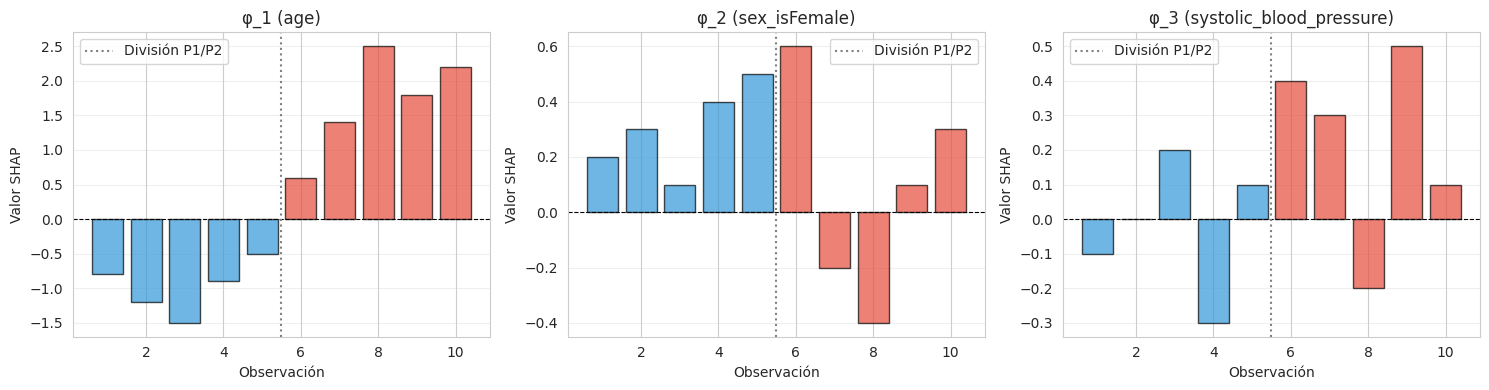

In [6]:
# Visualización 1: Valores SHAP por observación
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, var in enumerate(['phi_1', 'phi_2', 'phi_3'], 1):
    ax = axes[i-1]
    colors = ['#3498db' if p == 'P1' else '#e74c3c' for p in data['percentile']]
    ax.bar(data['obs'], data[var], color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(x=5.5, color='gray', linestyle=':', linewidth=1.5, label='División P1/P2')
    ax.set_xlabel('Observación')
    ax.set_ylabel('Valor SHAP')
    ax.set_title(f'φ_{i} ({variable_names[i-1]})')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

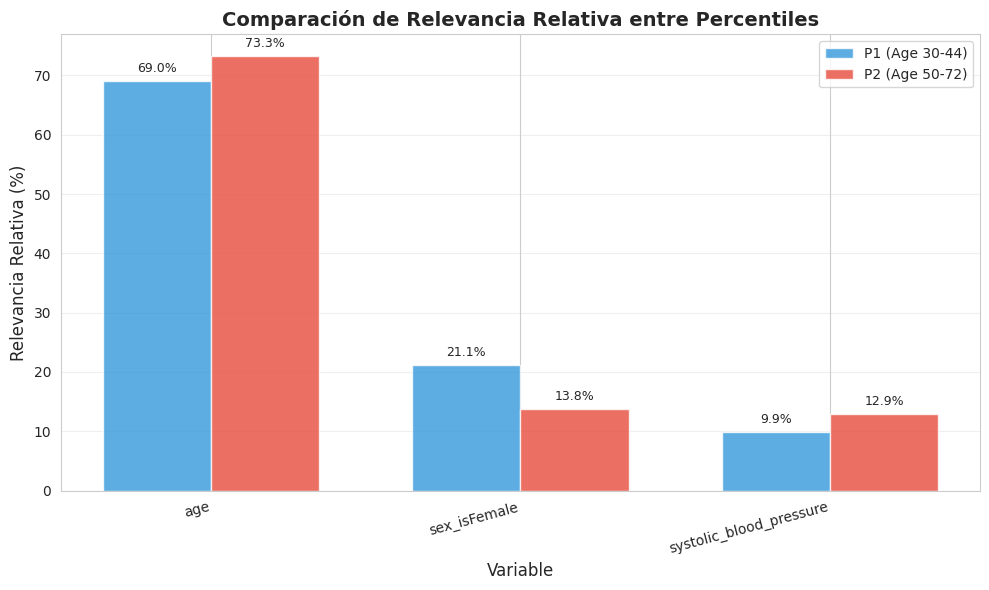

In [7]:
# Visualización 2: Comparación de Relevancia Relativa
pivot_df = results_df.pivot(index='Variable', columns='Percentile', values='Relative_Relevance')

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(variable_names))
width = 0.35

ax.bar(x - width/2, pivot_df['P1'], width, label='P1 (Age 30-44)', color='#3498db', alpha=0.8)
ax.bar(x + width/2, pivot_df['P2'], width, label='P2 (Age 50-72)', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Variable', fontsize=12)
ax.set_ylabel('Relevancia Relativa (%)', fontsize=12)
ax.set_title('Comparación de Relevancia Relativa entre Percentiles', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(variable_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(pivot_df['P1']):
    ax.text(i - width/2, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(pivot_df['P2']):
    ax.text(i + width/2, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

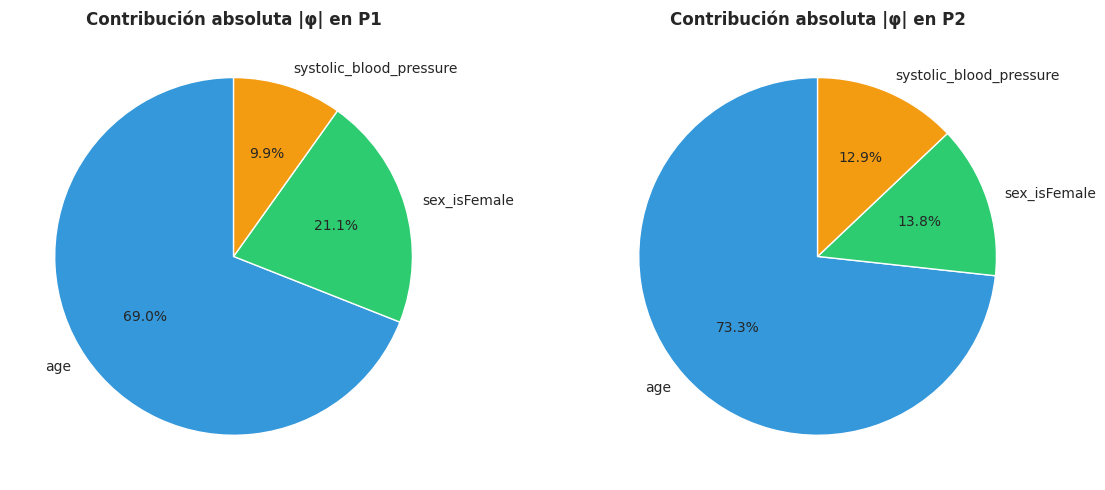

In [8]:
# Visualización 3: Contribución absoluta de SHAP por percentil
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, p in enumerate(['P1', 'P2']):
    p_data = data[data['percentile'] == p]
    contributions = [p_data[f'phi_{i}'].abs().sum() for i in [1, 2, 3]]
    
    colors_pie = ['#3498db', '#2ecc71', '#f39c12']
    axes[idx].pie(contributions, labels=variable_names, autopct='%1.1f%%', 
                  startangle=90, colors=colors_pie)
    axes[idx].set_title(f'Contribución absoluta |φ| en {p}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Resumen e Interpretación

In [9]:
print("RESUMEN DEL ANÁLISIS DE PERFILES DE INFLUENCIA")
print("="*80)
print(f"\nRelevancia Relativa de 'age' (variable de interés):")
print(f"  • Percentil 1 (edades 30-44): {R1_1:.2f}%")
print(f"  • Percentil 2 (edades 50-72): {R2_1:.2f}%")
print(f"\nDiferencia: {abs(R2_1 - R1_1):.2f} puntos porcentuales")

print("\nINTERPRETACIÓN:")
if R2_1 > R1_1:
    print(f"La variable 'age' tiene MAYOR relevancia en el percentil superior (P2).")
    print(f"Esto sugiere que la edad es más determinante para las predicciones")
    print(f"en personas de mayor edad (50-72 años).")
else:
    print(f"La variable 'age' tiene MAYOR relevancia en el percentil inferior (P1).")
    print(f"Esto sugiere que la edad es más determinante para las predicciones")
    print(f"en personas más jóvenes (30-44 años).")

print("\nNOTA: Los valores SHAP en P1 son mayormente negativos mientras que en P2")
print("son mayormente positivos, indicando que la edad tiene un efecto direccional")
print("en las predicciones del modelo.")
print("="*80)

RESUMEN DEL ANÁLISIS DE PERFILES DE INFLUENCIA

Relevancia Relativa de 'age' (variable de interés):
  • Percentil 1 (edades 30-44): 69.01%
  • Percentil 2 (edades 50-72): 73.28%

Diferencia: 4.26 puntos porcentuales

INTERPRETACIÓN:
La variable 'age' tiene MAYOR relevancia en el percentil superior (P2).
Esto sugiere que la edad es más determinante para las predicciones
en personas de mayor edad (50-72 años).

NOTA: Los valores SHAP en P1 son mayormente negativos mientras que en P2
son mayormente positivos, indicando que la edad tiene un efecto direccional
en las predicciones del modelo.
